<img src='../OUTILS/bandeau_MF.png' align='right' width='100%'/>

<div class="alert alert-info alert-success">
<h3>Élaboration d'image composite MTG / FCI avec SATPY </h3></div>

## <a id='TOC-TOP'></a>Contenus

<div class="alert alert-block alert-warning">
    
<b>PREREQUIS </b>
    
Ce Notebook ne nécessite pas de prérequis. 
Le kernel "env_MF_teledetection" doit être utilisé

</div>
<hr>

SatPy

Il s'agit d'une bibliothèque Python pour le traitement des données des satellites météorologiques

Satpy permet de lire, manipuler et écrire des données issues d'instruments satellites météorologiques d'observation de la Terre.

Satpy fournit la possibilité de lire les données de différents formats (readers) et de manipuler les paramètres géophysiques de ces différents formats de fichiers.

Satpy fournit également des interfaces pour créer des images RVB (rouge/vert/bleu) qui combinent les données de plusieurs bandes d'instruments ou produits.

Diverses corrections atmosphériques et améliorations visuelles sont fournies pour améliorer le rendu et la qualité des images de sortie. Les données de sortie peuvent être écrites dans plusieurs formats de fichiers tels que les fichiers NetCDF, PNG et GeoTIFF.

Satpy permet également aux utilisateurs de rééchantillonner les données sur des grilles géographiques projetées (zones).

Pour obtenir de la documentation sur Satpy, quelques exemples, et un tutoriel de démarrage rapide : https://satpy.readthedocs.io/en/latest/index.html

<div class="alert alert-info" role="alert">

### <a id='section1'></a>1.Tout d'abord, il faut procéder à l'importation des librairies nécessaires.

</div>

In [1]:
from satpy.scene import Scene
from satpy import find_files_and_readers
from datetime import datetime
import sys
from pyresample.geometry import AreaDefinition
import numpy as np
import os
from osgeo import gdal
from PIL import Image
import subprocess
from IPython.display import display,HTML
os.environ['PATH'] = f"/opt/conda/env_MF_teledetection/bin:{os.environ['PATH']}" 
os.environ['PATH'] = f"~/.conda/envs/env_MF_teledetection/bin:{os.environ['PATH']}"
os.environ['GDAL_DATA'] = '/opt/conda/env_MF_teledetection/share/gdal'
os.environ['PROJ_LIB'] = '/opt/conda/env_MF_teledetection/share/proj'

<div class="alert alert-info" role="alert">
    
### <a id='section2'></a>2.Définition du produit, date et heure, reader, et répertoires.

</div>

### Données d'entrée : fichiers chunk mtg (40) 
Pour télécharger d'autres fichiers, Cf. Jupyter Notebook  <a href="eumdac.ipynb" target="_blank"> Eumdac : téléchargement de données MTG</a></br>

In [8]:
input = '/stockage/DATA/202505141000/'

In [9]:
cd ~/MF_DATA_MANIPULATION

/home/coster/MF_DATA_MANIPULATION


In [10]:
download_dir = os.path.join(os.getcwd(), "RESULTS")
os.makedirs(download_dir, exist_ok=True)

In [11]:
output='RESULTS'

In [13]:
!ls $input |tail

W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514101020_IDPFI_OPE_20250514100726_20250514100818_N__O_0061_0032.nc
W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514101033_IDPFI_OPE_20250514100744_20250514100834_N__O_0061_0033.nc
W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514101045_IDPFI_OPE_20250514100752_20250514100850_N__O_0061_0034.nc
W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514101050_IDPFI_OPE_20250514100810_20250514100904_N__O_0061_0035.nc
W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514101056_IDPFI_OPE_20250514100834_20250514100917_N__O_0061_0037.nc
W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514101057_IDPFI_OPE_20250514100826_20250514100911_N__O_0061_0036.nc
W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---

### SATPY permet de produire notamment des RGB, parmi les suivantes
airmass ash </br>cimss_cloud_type</br> cloud_phase</br> cloudtop</br> convection</br> day_microphysics</br> dust</br> fog</br> green_snow</br> ir108_3d</br> ir_cloud_day</br> natural_color</br> ndvi_hybrid_green</br> night_fog</br> night_microphysics</br> rocket_plume_day</br> true_color</br> 

Définition du produit

In [15]:
composite_name = "cloud_phase"

### Définition de la date et heure de la composite à créer
(202401091200 disponible par défaut)

In [16]:
annee='2025'
mois='05'
jour='14'
heure='10'

In [17]:
yyyy=int(annee)
mm=int(mois)
dd=int(jour)
hh_debut=int(heure)
min_debut=int('00')
hh_fin=int(heure)
min_fin=int('10')

### Définition du reader

In [18]:
reader_to_use = "fci_l1c_nc"

In [19]:
filename = (output + '/RGB_satpy_' + composite_name )

In [20]:
myfiles = find_files_and_readers(base_dir=input,
                                 start_time=datetime(yyyy,mm,dd,hh_debut,min_debut),
                                 end_time=datetime(yyyy,mm,dd,hh_fin,min_fin),
                                 reader=reader_to_use)

In [22]:
!gdalinfo /stockage/DATA/202505141000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514100545_IDPFI_OPE_20250514100024_20250514100100_N__O_0061_0004.nc

Driver: netCDF/Network Common Data Format
Files: /stockage/DATA/202505141000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514100545_IDPFI_OPE_20250514100024_20250514100100_N__O_0061_0004.nc
Size is 512, 512
Metadata:
  /data/ir_105/NC_GLOBAL#long_name=FCI FDHSI Infrared 10.5 micron channel
  /data/ir_105/NC_GLOBAL#subsettable=yes
  /data/ir_105/quality_channel/NC_GLOBAL#long_name=Quality indicators applicable to a particular channel for the data chunk
  /data/ir_105/swath/NC_GLOBAL#long_name=Swath related information
  /data/ir_123/NC_GLOBAL#long_name=FCI FDHSI Infrared 12.3 micron channel
  /data/ir_123/NC_GLOBAL#subsettable=yes
  /data/ir_123/quality_channel/NC_GLOBAL#long_name=Quality indicators applicable to a particular channel for the data chunk
  /data/ir_123/swath/NC_GLOBAL#long_name=Swath related information
  /data/ir_133/NC_GLOBAL#long_name=FCI FDHSI Infrared 13.3 micron channel
  /data/ir_133/NC_GLOBAL#subsettable=yes
  /data/ir_133

In [23]:
!gdalinfo NETCDF:"/stockage/DATA/202505141000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514100545_IDPFI_OPE_20250514100024_20250514100100_N__O_0061_0004.nc":/data/vis_04/measured/pixel_quality

Warning 1: Unhandled X/Y axis unit radian. SRS will ignore axis unit and be likely wrong.
Driver: netCDF/Network Common Data Format
Files: /stockage/DATA/202505141000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514100545_IDPFI_OPE_20250514100024_20250514100100_N__O_0061_0004.nc
Size is 11136, 278
Coordinate System is:
PROJCRS["unnamed",
    BASEGEOGCRS["unknown",
        DATUM["unnamed",
            ELLIPSOID["Spheroid",6378137,298.25722356301,
                LENGTHUNIT["metre",1,
                    ID["EPSG",9001]]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433,
                ID["EPSG",9122]]]],
    CONVERSION["Geostationary Satellite (Sweep Y)",
        METHOD["Geostationary Satellite (Sweep Y)"],
        PARAMETER["Longitude of natural origin",0,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Satellite Height",35786400,
            LENGTHUNIT["metr

In [24]:
scn = Scene(filenames=myfiles)

### Liste de toutes les composites disponibles

In [25]:
print(scn.available_composite_names())

['24h_microphysics', 'airmass', 'ash', 'cimss_cloud_type', 'cimss_cloud_type_raw', 'cloud_phase', 'cloud_phase_distinction', 'cloud_phase_distinction_raw', 'cloud_phase_raw', 'cloud_phase_with_night_ir105', 'cloud_type', 'cloud_type_with_night_ir105', 'cloudtop', 'colorized_ir_clouds', 'convection', 'day_essl_colorized_low_level_moisture', 'day_essl_low_level_moisture', 'day_microphysics', 'day_severe_storms', 'day_severe_storms_tropical', 'dust', 'essl_colorized_low_level_moisture', 'essl_low_level_moisture', 'fci_fire_channels_sum', 'fire_temperature', 'fire_temperature_38refl', 'fire_temperature_rad', 'flames_masked', 'fog', 'geo_color', 'geo_color_background_with_low_clouds', 'geo_color_high_clouds', 'geo_color_low_clouds', 'geo_color_night', 'green_snow', 'hrv_clouds', 'ir108_3d', 'ir_cloud_day', 'ir_sandwich', 'ir_sandwich_with_night_colorized_ir_clouds', 'natural_color', 'natural_color_raw', 'ndvi_hybrid_green', 'ndvi_hybrid_green_fully_sunzencorrected', 'ndvi_hybrid_green_raw',

### Liste de tous les dataset disponibles

In [26]:
print(scn.available_dataset_names())

['ir_105', 'ir_105_earth_sun_distance', 'ir_105_index_map', 'ir_105_pixel_quality', 'ir_105_platform_altitude', 'ir_105_subsatellite_latitude', 'ir_105_subsatellite_longitude', 'ir_105_subsolar_latitude', 'ir_105_subsolar_longitude', 'ir_105_sun_satellite_distance', 'ir_105_swath_direction', 'ir_105_swath_number', 'ir_105_time', 'ir_123', 'ir_123_earth_sun_distance', 'ir_123_index_map', 'ir_123_pixel_quality', 'ir_123_platform_altitude', 'ir_123_subsatellite_latitude', 'ir_123_subsatellite_longitude', 'ir_123_subsolar_latitude', 'ir_123_subsolar_longitude', 'ir_123_sun_satellite_distance', 'ir_123_swath_direction', 'ir_123_swath_number', 'ir_123_time', 'ir_133', 'ir_133_earth_sun_distance', 'ir_133_index_map', 'ir_133_pixel_quality', 'ir_133_platform_altitude', 'ir_133_subsatellite_latitude', 'ir_133_subsatellite_longitude', 'ir_133_subsolar_latitude', 'ir_133_subsolar_longitude', 'ir_133_sun_satellite_distance', 'ir_133_swath_direction', 'ir_133_swath_number', 'ir_133_time', 'ir_38', 

<div class="alert alert-info" role="alert">
    
### <a id='section2'></a>3.Création du produit.

</div>

In [27]:
scn.load([composite_name], upper_right_corner='NE')

/home/coster/.conda/envs/env_MF_teledetection/lib/python3.10/site-packages/dask/array/core.py:813: FutureWarning: The `token=` keyword to `map_blocks` has been moved to `name=`. Please use `name=` instead as the `token=` keyword will be removed in a future release.
  warnings.warn(


In [28]:
natscn = scn.resample(scn.coarsest_area(), resampler='nearest')

In [29]:
natscn.save_dataset(composite_name, filename=filename + '.tif')

### Défnition de la taille de l'image globe (pixels)

In [31]:
taille_redim=800  # 5568x5568 par défaut

In [32]:
!identify {filename}.tif 

RESULTS/RGB_satpy_cloud_phase.tif TIFF 11136x11136 11136x11136+0+0 8-bit sRGB 198.681MiB 0.000u 0:00.000
identify: Unknown field with tag 33550 (0x830e) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.
identify: Unknown field with tag 33922 (0x8482) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.
identify: Unknown field with tag 34735 (0x87af) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.
identify: Unknown field with tag 34736 (0x87b0) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.
identify: Unknown field with tag 34737 (0x87b1) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.


In [35]:
!gdalwarp -overwrite -ts 2000 2000 {filename}.tif {filename}_redim.tif

Using band 4 of source image as alpha.
Creating output file that is 2000P x 2000L.
Processing RESULTS/RGB_satpy_cloud_phase.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.


In [36]:
!convert  {filename}_redim.tif {filename}_redim_HD.jpg > /dev/null 2>&1
!convert -resize 900 {filename}_redim.tif {filename}_redim.jpg > /dev/null 2>&1

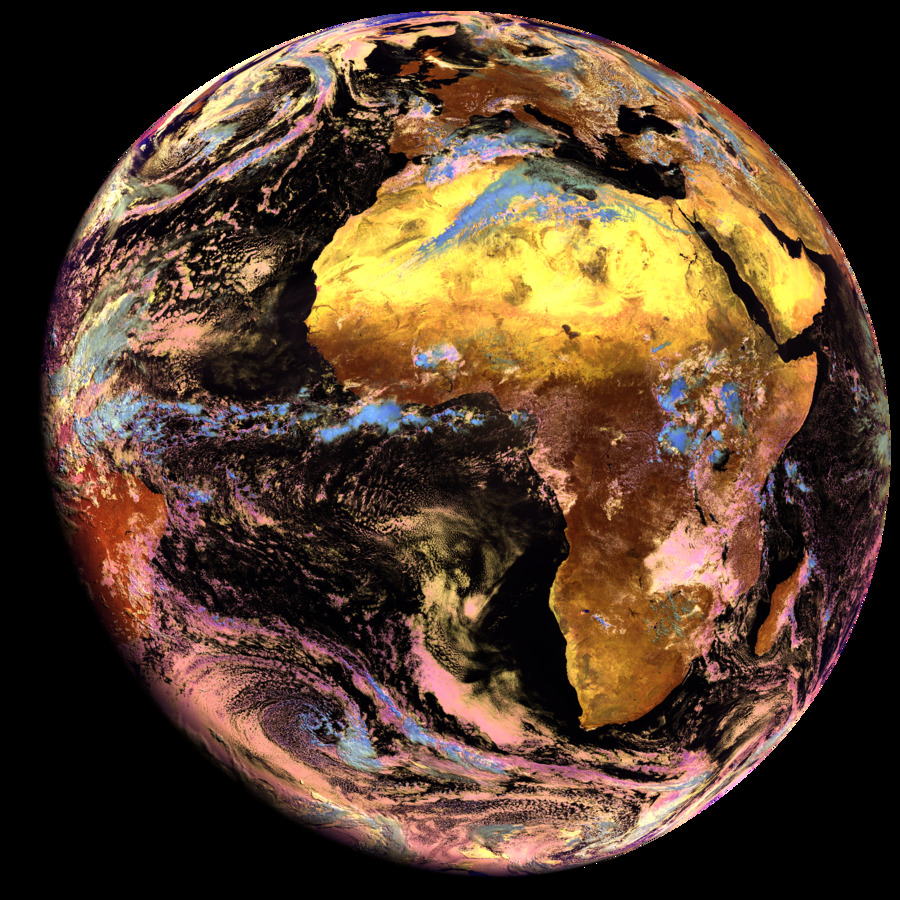

In [37]:
imgredim = Image.open(filename + '_redim.jpg')
display(imgredim)

In [ ]:
Quelques liens utiles:
## &emsp;&emsp;&emsp;<a href="../DOCS/Fiches_produits_MTG_legendes-RGB.pdf" target="_blank"><img src='../DOCS/mtg_fci_synthese_produits.jpg' alt='tableau synthèse' width='500px'> Principales légendes des produits RGB </a>


<div class="alert alert-info" role="alert">
    
### <a id='section2'></a>4.Pour aller plus loin, essayons de comprendre l'image que nous voyons, en extrayant les 3 bandes de ce produits RGB

</div>

In [38]:
!gdal_translate -q -b 1 {filename}_redim.tif {filename}_redim_bande_rouge.tif
!gdal_translate -q -b 2 {filename}_redim.tif {filename}_redim_bande_verte.tif
!gdal_translate -q -b 3 {filename}_redim.tif {filename}_redim_bande_bleue.tif
!convert -resize 300 {filename}_redim_bande_rouge.tif {filename}_redim_bande_rouge.jpg > /dev/null 2>&1
!convert -resize 300 {filename}_redim_bande_verte.tif {filename}_redim_bande_verte.jpg > /dev/null 2>&1
!convert -resize 300 {filename}_redim_bande_bleue.tif {filename}_redim_bande_bleue.jpg > /dev/null 2>&1

In [39]:
!gdalinfo {filename}.tif

Driver: GTiff/GeoTIFF
Files: RESULTS/RGB_satpy_cloud_phase.tif
Size is 11136, 11136
Coordinate System is:
PROJCRS["unknown",
    BASEGEOGCRS["unknown",
        DATUM["Unknown based on WGS 84 ellipsoid",
            ELLIPSOID["WGS 84",6378137,298.25722356301,
                LENGTHUNIT["metre",1],
                ID["EPSG",7030]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["Degree",0.0174532925199433]]],
    CONVERSION["unnamed",
        METHOD["Geostationary Satellite (Sweep Y)"],
        PARAMETER["Longitude of natural origin",0,
            ANGLEUNIT["Degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Satellite Height",35786400,
            LENGTHUNIT["metre",1,
                ID["EPSG",9001]]],
        PARAMETER["False easting",0,
            LENGTHUNIT["metre",1],
            ID["EPSG",8806]],
        PARAMETER["False northing",0,
            LENGTHUNIT["metre",1],
            ID["EPSG",8807]]],
    CS[Cartesian,2],
        AXIS["(E)",east,
   

Affichage des 3 images RGB Rouge Verte Bleue

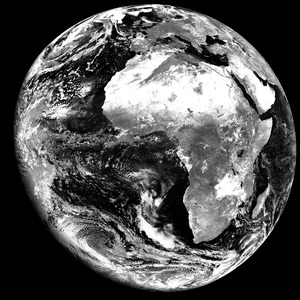

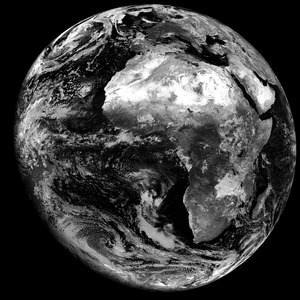

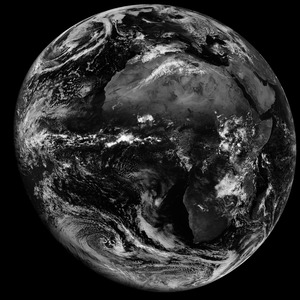

In [40]:
imgrouge = Image.open(filename + '_redim_bande_rouge.jpg')
display(imgrouge)
imgverte = Image.open(filename + '_redim_bande_verte.jpg')
display(imgverte)
imgbleue = Image.open(filename + '_redim_bande_bleue.jpg')
display(imgbleue)

Pour l'exemple du produit Cloud Phase RGB, les 3 bandes RGB sont celles respectivement associées aux canaux NIR1.60, NIR2.25 et VIS0.64, comme indiqué dans le document ci-dessous

### Document de synthèse des produits RGB FCI 

## &emsp;&emsp;&emsp;<a href="../DOCS/mtg_fci_synthese_produits.pdf" target="_blank"><img src='../DOCS/mtg_fci_synthese_produits.jpg' alt='tableau synthèse' width='500px'>  </a>

Autres exemples de visualisation d'un image composite rgb en 3 bandes rouge vert bleu : <a href="http://jupyter.fr-mf-general.s.ewcloud.host/user/coster/files/MF_DATA_MANIPULATION/DOCS/doc_mtg_fci_rgb_bande.html" title="lien "  > Ouvrir la page web de présentation ici</a>

### Ajout des frontières

In [ ]:
# Chemins vers les fichiers shapefile contenant les frontieres des pays : '../OUTILS/boundary/world-administrative-boundaries.shp' 

In [35]:
!gdal_rasterize -q -b 1 -burn 255 -b 2 -burn 255 -b 3 -burn 255 -l world-administrative-boundaries ../OUTILS/boundary/world-administrative-boundaries.shp {filename}.tif >/dev/null 2>&1 # frontière blanche
#!gdal_rasterize -q -b 1 -burn 255 -b 2 -burn 0 -b 3 -burn 0 -l world-administrative-boundaries ../OUTILS/boundary/world-administrative-boundaries.shp {filename}.tif >/dev/null 2>&1 # frontière rouge

### Affichage de l'image globe dans le jupyter notebook

In [ ]:
!convert -resize 800 {filename}.tif {filename}_min.jpg > /dev/null 2>&1

In [ ]:
!ls -lrth {filename}.tif {filename}_min.jpg

In [ ]:
!identify {filename}.tif {filename}_min.jpg

In [ ]:
im = Image.open(filename + '_min.jpg')
display(im)

In [ ]:
!echo {filename}_min.jpg

<div class="alert alert-info" role="alert">
    
### <a id='section2'></a>4.Création d'une image à partir d'une zone de découpe 

</div>

In [ ]:
### Définition de la zone, et redimmensionnement de l'image 

In [54]:
#exemple nord République du Congo = -12 2 30 6
coord_nord = 8
coord_sud = 0
coord_ouest = 17
coord_est = 33


In [55]:
# Facteur de mise à l'échelle
scale_factor = 0.04  # 0.04 par défaut

In [56]:
#Exemple de passage en système de coordonnées géographiques (GCS) système de coordonnées WGS84 afin d'utiliser des coordonnées en degrés ("EPSG:4326", similaire à cylindrique équidistant
#Définition de la zone de découpe (étendue géographique) -te (target extent) en degrés

In [57]:
!gdalwarp -overwrite -t_srs "EPSG:4326" -te {coord_ouest} {coord_sud} {coord_est} {coord_nord}  {filename}.tif {filename}_decoupe_HD.tif
!gdalwarp -overwrite -t_srs "EPSG:4326" -te {coord_ouest} {coord_sud} {coord_est} {coord_nord}  {filename}.tif {filename}_decoupe_HD.png
!gdalwarp -overwrite -t_srs "EPSG:4326" -te {coord_ouest} {coord_sud} {coord_est} {coord_nord} {filename}.tif {filename}_decoupe_HD.jpg

Using band 4 of source image as alpha.
Creating output file that is 1689P x 845L.
Processing OUTPUT/RGB_cloud_phase.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Using band 4 of source image as alpha.
Creating output file that is 1689P x 845L.
0...10...20...30...40...50...60...70...80...90...100 - done.
Using band 4 of source image as alpha.
Creating output file that is 1689P x 845L.
Warning 1: 4-band JPEGs will be interpreted on reading as in CMYK colorspace
0...10...20...30...40...50...60...70...80...90...100 - done.


In [58]:
### Affichage des différentes tailles de fichiers

In [59]:
!ls -lhtr {filename}_decoupe_HD.tif {filename}_decoupe_HD.png {filename}_decoupe_HD.jpg 

-rw-r--r--. 1 coster coster 5.5M Sep 18 16:14 OUTPUT/RGB_cloud_phase_decoupe_HD.tif
-rw-r--r--. 1 coster coster 2.8M Sep 18 16:14 OUTPUT/RGB_cloud_phase_decoupe_HD.png
-rw-r--r--. 1 coster coster 725K Sep 18 16:14 OUTPUT/RGB_cloud_phase_decoupe_HD.jpg


In [60]:
!identify {filename}_decoupe_HD.tif {filename}_decoupe_HD.png {filename}_decoupe_HD.jpg 

OUTPUT/RGB_cloud_phase_decoupe_HD.tif TIFF 1689x845 1689x845+0+0 8-bit sRGB 5.4496MiB 0.000u 0:00.000
OUTPUT/RGB_cloud_phase_decoupe_HD.png PNG 1689x845 1689x845+0+0 8-bit sRGB 2.74232MiB 0.000u 0:00.000
OUTPUT/RGB_cloud_phase_decoupe_HD.jpg JPEG 1689x845 1689x845+0+0 8-bit CMYK 741847B 0.000u 0:00.000
identify: Unknown field with tag 33550 (0x830e) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.
identify: Unknown field with tag 33922 (0x8482) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.
identify: Unknown field with tag 34735 (0x87af) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.
identify: Unknown field with tag 34736 (0x87b0) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.
identify: Unknown field with tag 34737 (0x87b1) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.


In [61]:
!convert -resize 2000 {filename}_decoupe_HD.png {filename}_decoupe_min.jpg
!ls -lhtr {filename}_decoupe_min.jpg


-rw-r--r--. 1 coster coster 762K Sep 18 16:14 OUTPUT/RGB_cloud_phase_decoupe_min.jpg


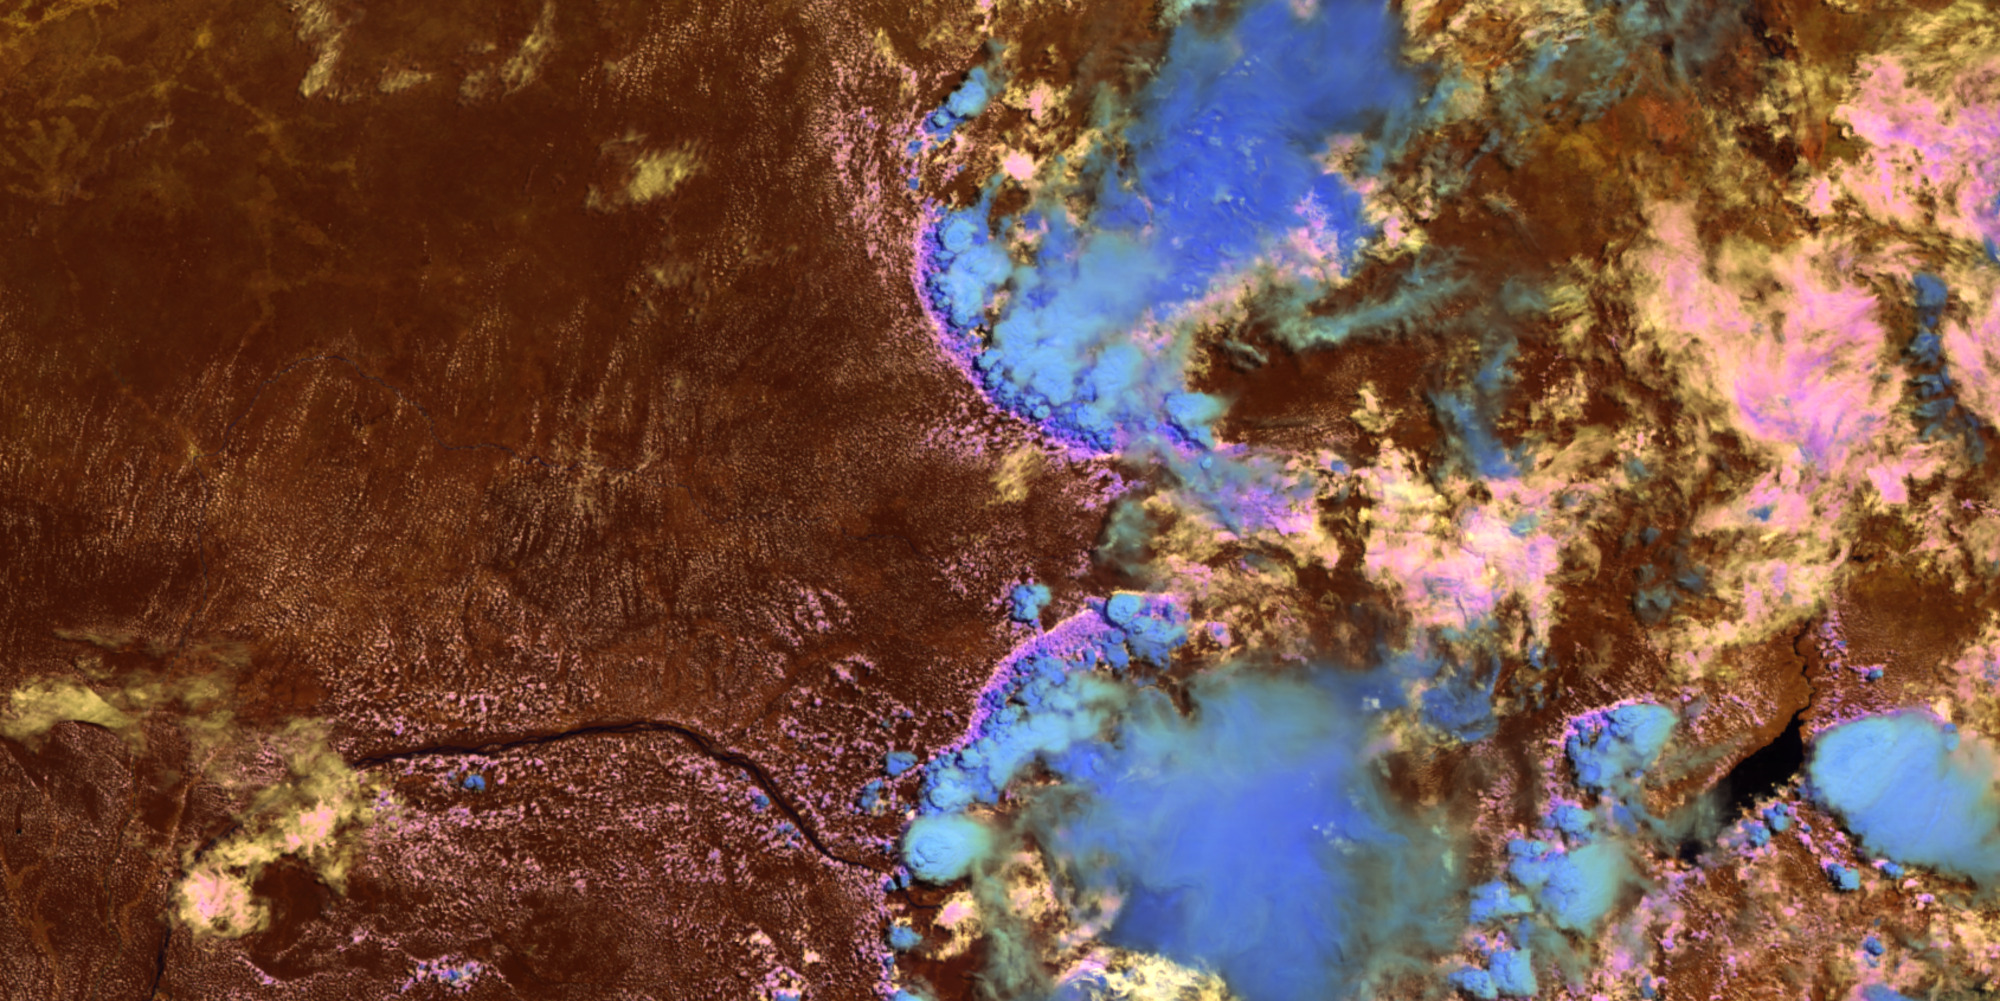

In [62]:
im2 = Image.open(filename + '_decoupe_min.jpg')
display(im2)

<div class="alert alert-info" role="alert">
    
### <a id='section2'></a>5. Reprojection de l'image

</div>


#### Définition de la reprojection et de la zone de découpe de l'image à reprojeter

In [ ]:
#Exemple pour la projection orthographique ("ortho"):
#Modification des coordonnées du centre de l'image lat et lon
#Définition du redimmensionnent de l'image (facultatif) en spécifiant la largeur et la hauteur : option -ts (target size) en pixels
#Définition de la zone de découpe (étendue géographique) -te (target extent) en mètres
#Attention à conserver les proportions largeur/hauteur entre les options -ts et -te


In [ ]:
!gdalwarp -q -overwrite -t_srs "+proj=ortho +lat_0=46 +lon_0=3" -ts 3200 1800 -te -1600000 -900000 1600000 900000 {filename}.tif {filename}_ortho.jpg

In [ ]:
!convert -resize 800 {filename}_ortho.jpg {filename}_ortho_min.png

In [ ]:
im3 = Image.open(filename + '_ortho_min.png')
display(im3)

In [ ]:
#!gdalwarp -q -overwrite -t_srs "+proj=ortho +lat_0=10 +lon_0=6" -ts 3000 2300 -te -1600000 -900000 1600000 900000 {filename}.tif {filename}_zoom_onde-est.jpg
!gdalwarp -overwrite -t_srs "EPSG:4326" -te 2 5 18 16  {filename}.tif {filename}.tif {filename}_zoom_onde-est.jpg # (coord W S E N)

In [ ]:
!convert -resize 800 {filename}_zoom_onde-est.jpg {filename}_zoom_onde-est_min.png

In [ ]:
imgonde = Image.open(filename + '_zoom_onde-est_min.png')
display(imgonde)

### Ajout texte et logo

In [ ]:
!convert {filename}_zoom_onde-est_min.png -font DejaVu-Sans -pointsize 17 -fill '#ffffff'  -annotate +30+30 "{composite_name} RGB le {jour}/{mois}/{annee} à {heure} h UTC" {filename}_ortho_min_annotee.jpg

In [ ]:
!convert {filename}_ortho_min_annotee.jpg ../OUTILS/logo_mf_min_100x100.png  -gravity SouthEast -geometry +20+20 -composite {filename}_finale.jpg

In [ ]:
im5 = Image.open(filename + '_finale.jpg')
display(im5)

Exemples d'animations réalisées

<a href="http://jupyter.fr-mf-general.s.ewcloud.host/user/coster/files/MF_DATA_MANIPULATION/DOCS/20240923_mtg_cloudphase_afrique-centrale_loop_ld.mp4" title="lien "  > Animation cloudphase onde d'est </a>

<a href="http://jupyter.fr-mf-general.s.ewcloud.host/user/coster/files/MF_DATA_MANIPULATION/DOCS/20240923_mtg_compar9_afrique-centrale_ld.mp4" title="lien "  > Animation comparaison produits onde d'est </a>

### Nettoyage

In [ ]:
!rm {output}/*xml #{output}/*.tif

In [ ]:
#!rm -f {output}/*


<div class="alert alert-info" role="alert">

### <a id='section1'></a>Exercice : créer une autre image composite RGB avec satpy et découper sur une autre zone avec GDAL. 
### (chunks_mtg_20240912  chunks_mtg_20240923  chunks_mtg_20241008)

</div>